# Computer Vision Tutorial: Convolutional Neural Networks (CNN) with CIFAR-100

*   Adapted from the guided book chapter 3.7 "Project: Image Classification for Color Images"
*   Original code at book's website: https://github.com/moelgendy/deep_learning_for_vision_systems/blob/master/chapter_03/chapter_3_cifar10_cnn.ipynb
*   Modified for CIFAR-100 coarse classification (20 categories)

---

In this notebook, we train a CNN to classify images from the CIFAR-100 database using the coarse labels (20 general categories).

## 1. Load CIFAR-100 Database

*   Dataset description available at: https://www.cs.toronto.edu/~kriz/cifar.html
*   Also, it is available at: https://keras.io/api/datasets/cifar100/

In [1]:
import keras
from keras.datasets import cifar100

# load the pre-shuffled train and test data with coarse labels (20 categories)
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='coarse')

I0000 00:00:1773276568.325345    6031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773276569.209657    6031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773276571.748670    6031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/ervin/Desktop/taller-1-/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## 2. Visualize the First 24 Training Images

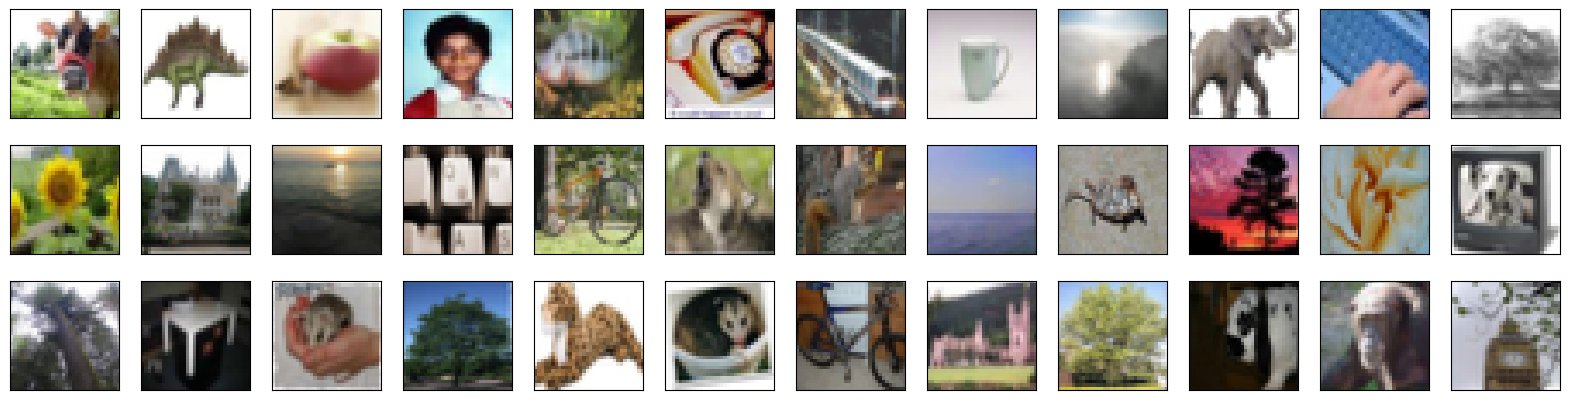

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_train[i]))

## 3. **Image preprocessing**

### 3.1. Rescale the Images by Dividing Every Pixel in Every Image by 255


In [3]:
# rescale [0,255] --> [0,1]
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

### 3.2. Data Augmentation and Break Dataset into Training, Testing, and Validation Sets

* Apply data augmentation techniques (flip, rotation, zoom, shift) to enhance training data
* Prepare the labels using **One Hot Encoding**.
* Split the data into train, validation and test datasets.

In [4]:
# one-hot encode the labels
num_classes = len(np.unique(y_train))
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# break training set into training and validation sets (proportionally adjusted for CIFAR-100)
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# print shape of training set
print('x_train shape:', x_train.shape)

# print number of training, validation, and test images
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_valid.shape[0], 'validation samples')
print(num_classes, 'classes')

# Data augmentation using ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.15,
    fill_mode='nearest'
)

# Note: datagen will be used during model.fit_generator() for training

x_train shape: (45000, 32, 32, 3)
45000 train samples
10000 test samples
5000 validation samples
20 classes


### 4. Define the CNN Model Architecture



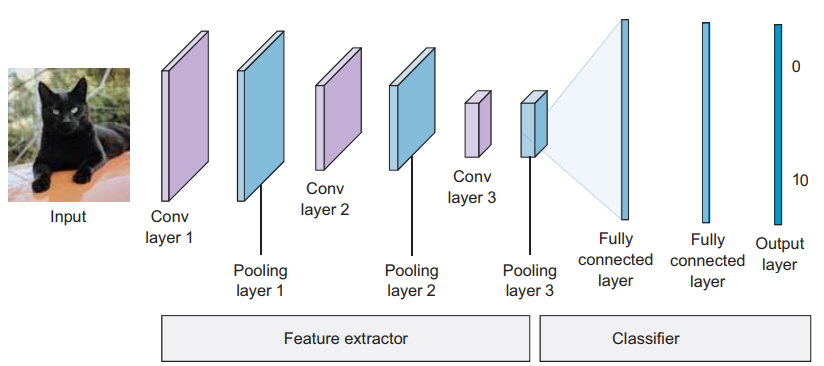

In [5]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Build improved CNN model for CIFAR-100 classification
model = Sequential()

# Block 1: First convolutional block
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu',
                  input_shape=x_train.shape[1:]))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

# Block 2: Second convolutional block
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))

# Block 3: Third convolutional block
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))

# Fully connected layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/home/ervin/Desktop/taller-1-/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773276577.199041    6031 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773276577.200650    6058 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1773276577.219493    6031 cuda_executor.cc:1827] Nvml call failed with 3(Not Supported). Assuming PCIe gen 3 x16 bandwidth.
W0000 00:00:1773276577.220580    603

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,477,428 (5.64 MB)

 Trainable params: 1,474,996 (5.63 MB)

 Non-trainable params: 2,432 (9.50 KB)

### 5. Compile the Model

The last step before training our model is to define three more hyperparameters to monitor during training and testing:

* Loss (error) function: How the network will be able to measure its performance on the
training data.
* Optimizer: The mechanism that the network will use to optimize its parameters
(weights and biases) to yield the minimum loss value. It is usually one of the
variants of stochastic gradient descent.

* Metrics: List of metrics to be evaluated by the model during training and testing. Typically we use metrics=['accuracy'].

In [6]:
# compile the model with Adam optimizer for better convergence
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(learning_rate=0.001), 
              metrics=['accuracy'])

### 6. Train the Model

In [7]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpointer = ModelCheckpoint(filepath='model.best.weights.h5', verbose=0, save_weights_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# train the model with data augmentation using fit_generator
# This improves generalization by augmenting training data in real-time
hist = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=35,
    validation_data=(x_valid, y_valid), 
    callbacks=[checkpointer, early_stop],
    verbose=1,
    steps_per_epoch=100
)

Epoch 1/35


I0000 00:00:1773276577.964476    6031 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 688ms/step - accuracy: 0.1173 - loss: 3.3499 - val_accuracy: 0.0570 - val_loss: 3.2438
Epoch 2/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 658ms/step - accuracy: 0.1752 - loss: 2.8079 - val_accuracy: 0.0724 - val_loss: 3.4779
Epoch 3/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 653ms/step - accuracy: 0.2006 - loss: 2.6602 - val_accuracy: 0.0814 - val_loss: 3.1641
Epoch 4/35
 52/100 ━━━━━━━━━━━━━━━━━━━━ 29s 620ms/step - accuracy: 0.2097 - loss: 2.6058

/home/ervin/Desktop/taller-1-/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 356ms/step - accuracy: 0.2162 - loss: 2.5901 - val_accuracy: 0.0886 - val_loss: 3.1423
Epoch 5/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 658ms/step - accuracy: 0.2312 - loss: 2.5309 - val_accuracy: 0.1716 - val_loss: 2.8366
Epoch 6/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 632ms/step - accuracy: 0.2505 - loss: 2.4377 - val_accuracy: 0.2678 - val_loss: 2.3210
Epoch 7/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 663ms/step - accuracy: 0.2578 - loss: 2.3992 - val_accuracy: 0.2258 - val_loss: 2.6650
Epoch 8/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 356ms/step - accuracy: 0.2829 - loss: 2.3593 - val_accuracy: 0.3124 - val_loss: 2.1773
Epoch 9/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 64s 638ms/step - accuracy: 0.2838 - loss: 2.3293 - val_accuracy: 0.2946 - val_loss: 2.2360
Epoch 10/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 64s 638ms/step - accuracy: 0.2918 - loss: 2.2843 - val_accuracy: 0.3080 - val_loss: 2.2425
Epoch 11/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 635ms/step - accuracy: 0.3044 - loss: 2.2277 - v

Check learning curves of model accuracy and loss values

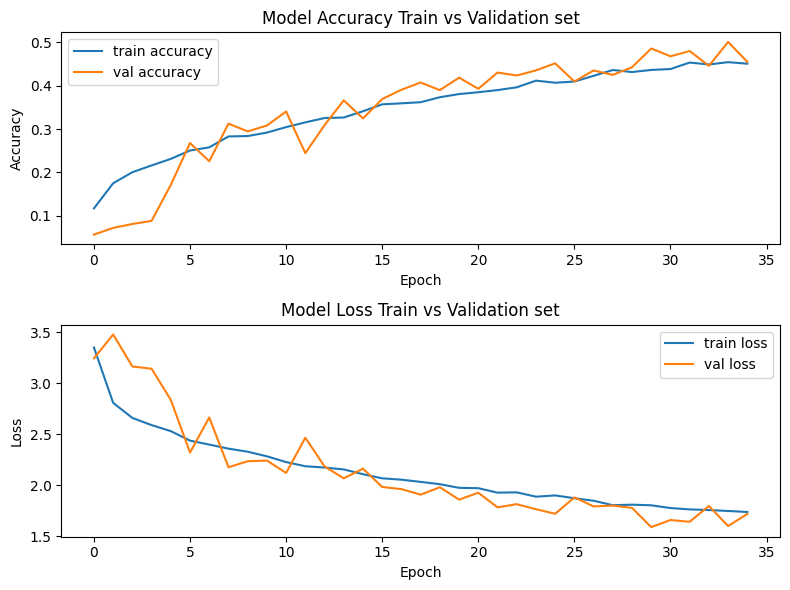

In [8]:
# plot learning curves of model

plt.figure(figsize=(8, 6))

# ---- Subplot 1: Accuracy ----
plt.subplot(2, 1, 1)
plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy Train vs Validation set')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# ---- Subplot 2: Loss ----
plt.subplot(2, 1, 2)
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='val loss')
plt.title('Model Loss Train vs Validation set')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

### 7. Evaluation of the trained model

#### 7.1. Load the Model with the Best Validation Accuracy

In [9]:
# load the weights that yielded the best validation accuracy
model.load_weights('model.best.weights.h5')

#### 7.2. Calculate Classification Accuracy on Test Set

In [10]:
# evaluate and print test accuracy
score = model.evaluate(x_test, y_test, verbose=0)
print('\n', 'Test accuracy:', score[1])

W0000 00:00:1773278623.148842    6031 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.



 Test accuracy: 0.45879998803138733


#### 7.3. Visualize Some Predictions

This may give you some insight into why the network is misclassifying certain objects.

In [11]:
# get predictions on the test set
y_hat = model.predict(x_test)

# define coarse text labels for CIFAR-100 (20 categories)
# source: https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
cifar100_coarse_labels = [
    'aquatic_mammals',                  # 0
    'fish',                             # 1
    'flowers',                          # 2
    'food_containers',                  # 3
    'fruit_and_vegetables',             # 4
    'household_electrical_devices',     # 5
    'household_furniture',              # 6
    'insects',                          # 7
    'large_carnivores',                 # 8
    'large_man-made_outdoor_things',    # 9
    'large_natural_outdoor_scenes',     # 10
    'large_omnivores_and_herbivores',   # 11
    'medium_mammals',                   # 12
    'non-insect_invertebrates',         # 13
    'people',                           # 14
    'reptiles',                         # 15
    'small_mammals',                    # 16
    'trees',                            # 17
    'vehicles_1',                       # 18
    'vehicles_2'                        # 19
]

W0000 00:00:1773278629.688669    6031 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


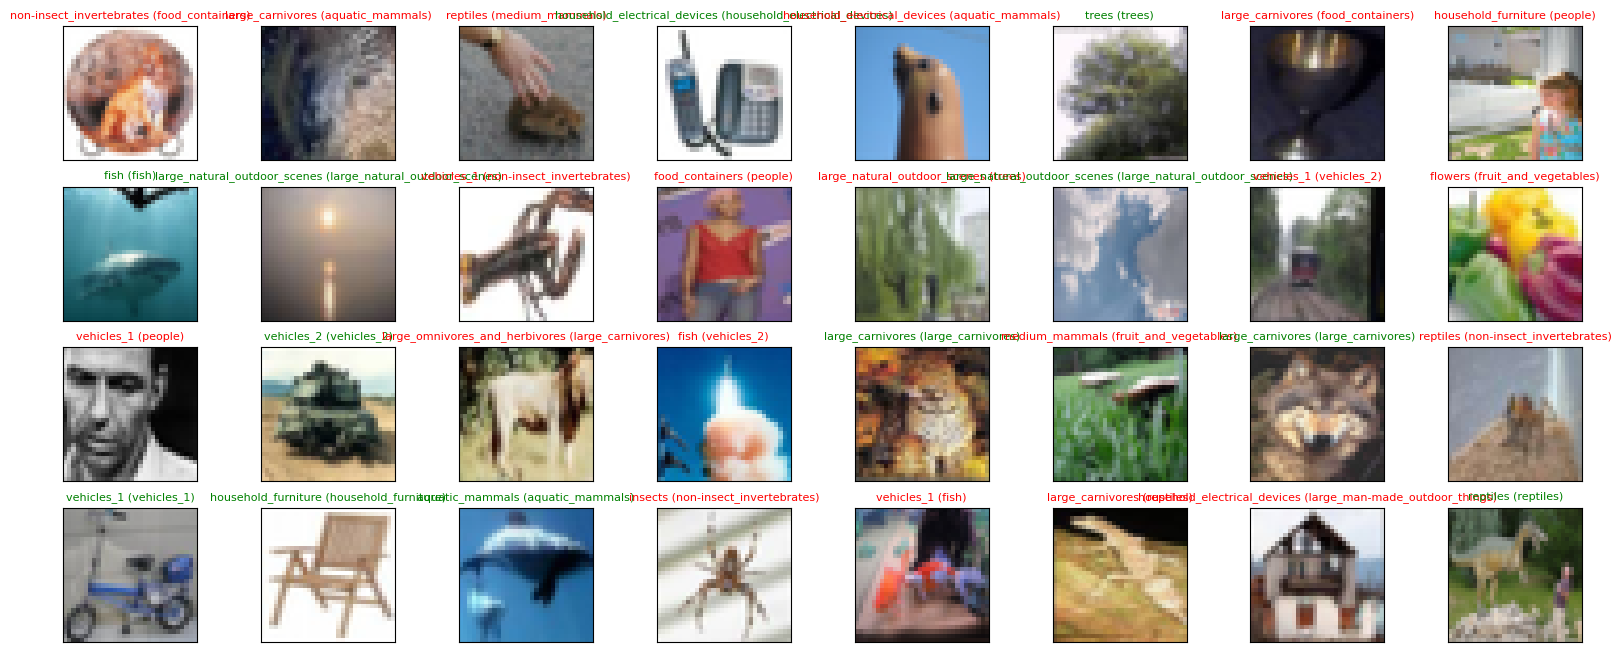

In [12]:
# plot a random sample of test images, their predicted labels, and ground truth
fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test[idx]))
    pred_idx = np.argmax(y_hat[idx])
    true_idx = np.argmax(y_test[idx])
    ax.set_title("{} ({})".format(cifar100_coarse_labels[pred_idx], cifar100_coarse_labels[true_idx]),
                 color=("green" if pred_idx == true_idx else "red"), fontsize=8)

## 8. Hyperparameter Tuning: Training Multiple Models

This section trains and evaluates multiple CNN models with different hyperparameters to demonstrate the effect of learning rate and epochs on model performance.

In [13]:
### 8.1 Model 2: SGD con Momentum - Diferente Optimizador y Learning Rate

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import SGD

# Build second CNN model - same architecture but with SGD optimizer
model2 = Sequential()

# Block 1
model2.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu',
                   input_shape=x_train.shape[1:]))
model2.add(BatchNormalization())
model2.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=2))
model2.add(Dropout(0.2))

# Block 2
model2.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=2))
model2.add(Dropout(0.3))

# Block 3
model2.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=2))
model2.add(Dropout(0.3))

# Fully connected layers
model2.add(Flatten())
model2.add(Dense(512, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))
model2.add(Dense(256, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.4))
model2.add(Dense(num_classes, activation='softmax'))

# Compile with SGD optimizer + momentum (diferente al Adam del Modelo 1)
model2.compile(loss='categorical_crossentropy',
               optimizer=SGD(learning_rate=0.01, momentum=0.9),
               metrics=['accuracy'])

model2.summary()

# Train model 2
checkpointer2 = ModelCheckpoint(filepath='model2.best.weights.h5', verbose=0, save_weights_only=True)
early_stop2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hist2 = model2.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=60,
    validation_data=(x_valid, y_valid),
    callbacks=[checkpointer2, early_stop2],
    verbose=1,
    steps_per_epoch=100
)

print("Model 2 (SGD) training completed")
print("Test accuracy Model 2:", model2.evaluate(x_test, y_test, verbose=0)[1])


/home/ervin/Desktop/taller-1-/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,477,428 (5.64 MB)

 Trainable params: 1,474,996 (5.63 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 591ms/step - accuracy: 0.0999 - loss: 3.3681 - val_accuracy: 0.1172 - val_loss: 2.8370
Epoch 2/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 584ms/step - accuracy: 0.1503 - loss: 2.8341 - val_accuracy: 0.1074 - val_loss: 2.9660
Epoch 3/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 605ms/step - accuracy: 0.1792 - loss: 2.7123 - val_accuracy: 0.1922 - val_loss: 2.6017
Epoch 4/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 318ms/step - accuracy: 0.1968 - loss: 2.6389 - val_accuracy: 0.2166 - val_loss: 2.5165
Epoch 5/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 110s 586ms/step - accuracy: 0.1977 - loss: 2.6117 - val_accuracy: 0.2138 - val_loss: 2.5208
Epoch 6/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 585ms/step - accuracy: 0.2128 - loss: 2.5537 - val_accuracy: 0.2570 - val_loss: 2.4163
Epoch 7/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 587ms/step - accuracy: 0.2245 - loss: 2.5167 - val_accuracy: 0.2592 - val_loss: 2.3612
Epoch 8/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - accuracy: 0.2341 - loss: 

W0000 00:00:1773281985.064786    6031 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


Test accuracy Model 2: 0.4717999994754791


In [14]:
### 8.2 Model 3: RMSprop - Arquitectura Mejorada con Diferente Optimizador

from keras.optimizers import RMSprop

# Build third CNN model - enhanced architecture with RMSprop optimizer
model3 = Sequential()

# Enhanced Block 1 with more filters
model3.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu',
                   input_shape=x_train.shape[1:]))
model3.add(BatchNormalization())
model3.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.25))

# Enhanced Block 2
model3.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.35))

# Enhanced Block 3
model3.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.35))

# Fully connected layers
model3.add(Flatten())
model3.add(Dense(768, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.5))
model3.add(Dense(384, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.4))
model3.add(Dense(num_classes, activation='softmax'))

# Compile with RMSprop optimizer (diferente al Adam y SGD de los modelos anteriores)
model3.compile(loss='categorical_crossentropy',
               optimizer=RMSprop(learning_rate=0.0005),
               metrics=['accuracy'])

model3.summary()

# Train model 3
checkpointer3 = ModelCheckpoint(filepath='model3.best.weights.h5', verbose=0, save_weights_only=True)
early_stop3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hist3 = model3.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=50,
    validation_data=(x_valid, y_valid),
    callbacks=[checkpointer3, early_stop3],
    verbose=1,
    steps_per_epoch=100
)

print("Model 3 (RMSprop) training completed")
print("Test accuracy Model 3:", model3.evaluate(x_test, y_test, verbose=0)[1])


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 768)            │     3,146,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,603,092 (17.56 MB)

 Trainable params: 4,598,996 (17.54 MB)

 Non-trainable params: 4,096 (16.00 KB)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.1230 - loss: 3.3895 - val_accuracy: 0.0498 - val_loss: 3.4250
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.1696 - loss: 2.9177 - val_accuracy: 0.0584 - val_loss: 4.0532
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.2115 - loss: 2.7162 - val_accuracy: 0.0548 - val_loss: 4.2652
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 719ms/step - accuracy: 0.2206 - loss: 2.6212 - val_accuracy: 0.0774 - val_loss: 3.4654
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.2411 - loss: 2.5509 - val_accuracy: 0.1852 - val_loss: 2.6949
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.2719 - loss: 2.4246 - val_accuracy: 0.2596 - val_loss: 2.4345
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.2903 - loss: 2.3566 - val_accuracy: 0.3508 - val_loss: 2.0990
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 722ms/step - accuracy: 0.3078 - loss: 2.3110 - val_

W0000 00:00:1773288378.862246    6031 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


Test accuracy Model 3: 0.5971999764442444


In [15]:
### 8.3 Comparación de Rendimiento de los 3 Modelos

# Compare performance metrics of all three models
print("=" * 70)
print("COMPARACIÓN DE MODELOS CNN PARA CIFAR-100 (20 CLASES COARSE)")
print("=" * 70)

test_loss_m1, test_acc_m1 = model.evaluate(x_test, y_test, verbose=0)
test_loss_m2, test_acc_m2 = model2.evaluate(x_test, y_test, verbose=0)
test_loss_m3, test_acc_m3 = model3.evaluate(x_test, y_test, verbose=0)

print(f"\nModelo 1 - Arquitectura Estándar | Optimizador: Adam | LR=0.001 | Epochs: {len(hist.history['loss'])}")
print(f"  Test Accuracy: {test_acc_m1:.4f}  |  Test Loss: {test_loss_m1:.4f}")

print(f"\nModelo 2 - Arquitectura Estándar | Optimizador: SGD (momentum=0.9) | LR=0.01 | Epochs: {len(hist2.history['loss'])}")
print(f"  Test Accuracy: {test_acc_m2:.4f}  |  Test Loss: {test_loss_m2:.4f}")

print(f"\nModelo 3 - Arquitectura Mejorada | Optimizador: RMSprop | LR=0.0005 | Epochs: {len(hist3.history['loss'])}")
print(f"  Test Accuracy: {test_acc_m3:.4f}  |  Test Loss: {test_loss_m3:.4f}")

print("\n" + "=" * 70)
best_model_idx = np.argmax([test_acc_m1, test_acc_m2, test_acc_m3])
best_model_names = ["Modelo 1 (Adam)", "Modelo 2 (SGD)", "Modelo 3 (RMSprop)"]
print(f"Mejor modelo: {best_model_names[best_model_idx]}")
print("=" * 70)


COMPARACIÓN DE MODELOS CNN PARA CIFAR-100 (20 CLASES COARSE)


W0000 00:00:1773288399.560939    6031 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.



Modelo 1 - Arquitectura Estándar | Optimizador: Adam | LR=0.001 | Epochs: 35
  Test Accuracy: 0.4588  |  Test Loss: 1.7070

Modelo 2 - Arquitectura Estándar | Optimizador: SGD (momentum=0.9) | LR=0.01 | Epochs: 60
  Test Accuracy: 0.4718  |  Test Loss: 1.6577

Modelo 3 - Arquitectura Mejorada | Optimizador: RMSprop | LR=0.0005 | Epochs: 50
  Test Accuracy: 0.5972  |  Test Loss: 1.2675

Mejor modelo: Modelo 3 (RMSprop)


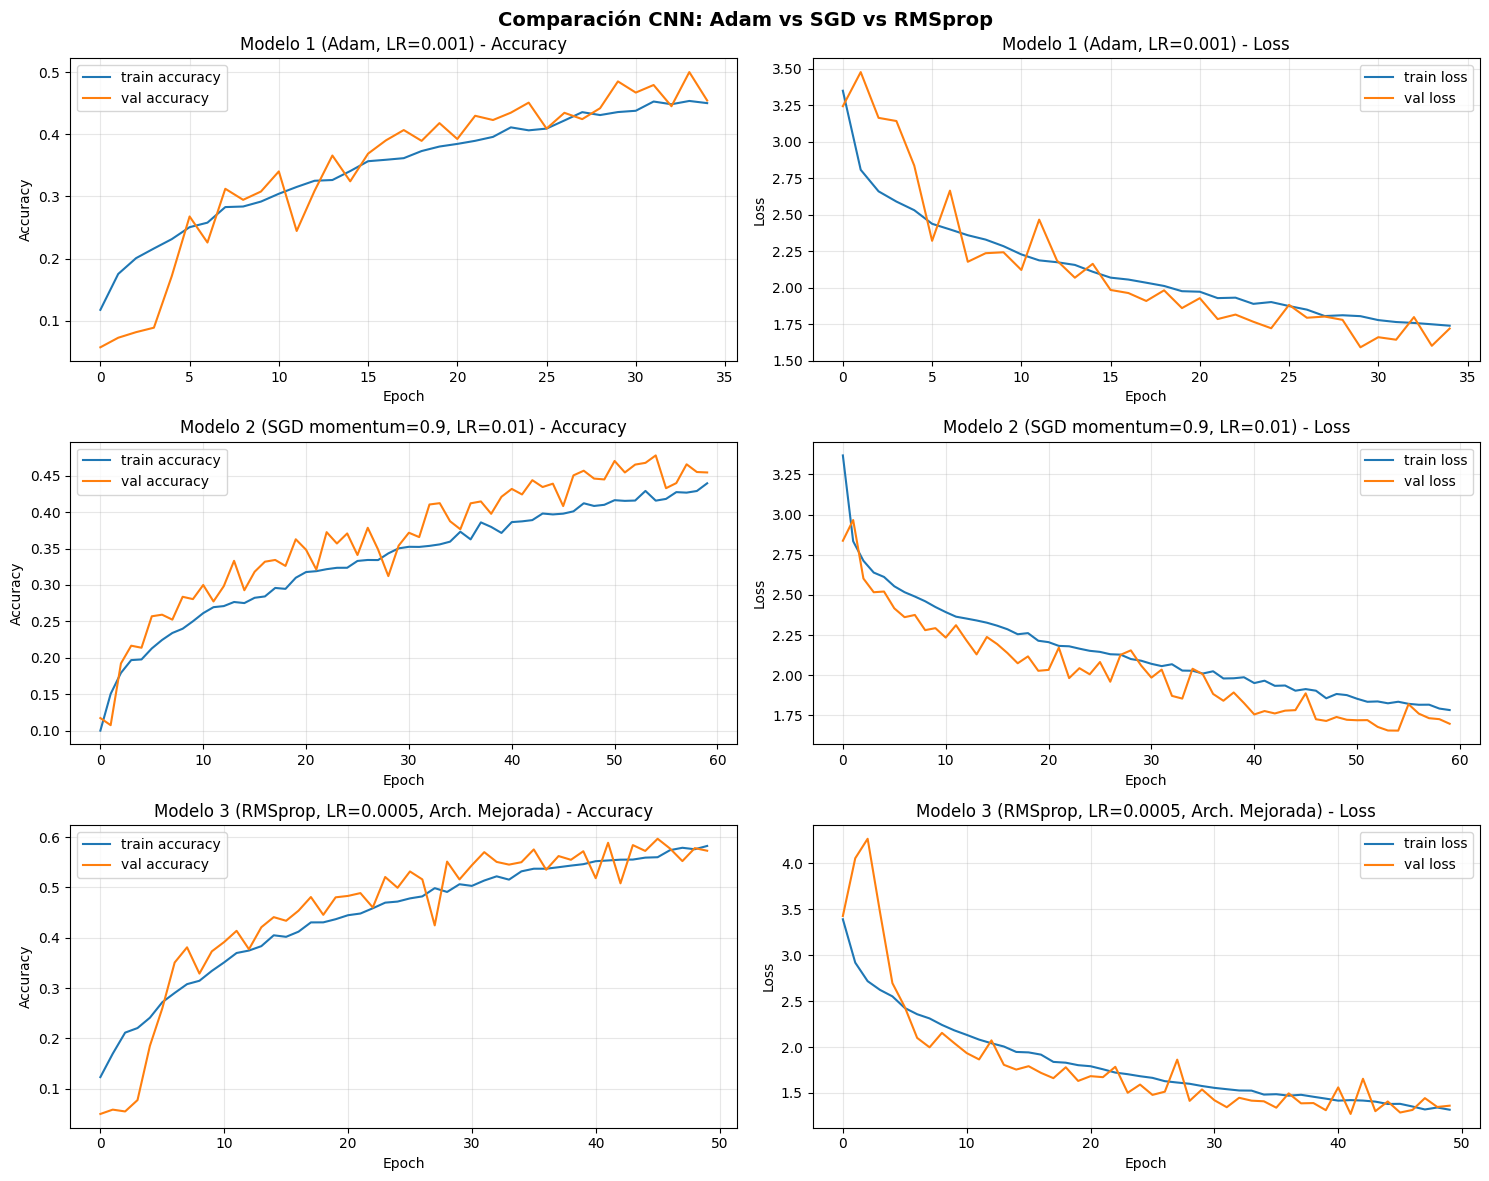

In [16]:
### 8.4 Curvas de Aprendizaje - Comparación de los 3 Modelos

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Comparación CNN: Adam vs SGD vs RMSprop', fontsize=14, fontweight='bold')

# Model 1 - Adam
axes[0, 0].plot(hist.history['accuracy'], label='train accuracy')
axes[0, 0].plot(hist.history['val_accuracy'], label='val accuracy')
axes[0, 0].set_title('Modelo 1 (Adam, LR=0.001) - Accuracy')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(hist.history['loss'], label='train loss')
axes[0, 1].plot(hist.history['val_loss'], label='val loss')
axes[0, 1].set_title('Modelo 1 (Adam, LR=0.001) - Loss')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Model 2 - SGD
axes[1, 0].plot(hist2.history['accuracy'], label='train accuracy')
axes[1, 0].plot(hist2.history['val_accuracy'], label='val accuracy')
axes[1, 0].set_title('Modelo 2 (SGD momentum=0.9, LR=0.01) - Accuracy')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(hist2.history['loss'], label='train loss')
axes[1, 1].plot(hist2.history['val_loss'], label='val loss')
axes[1, 1].set_title('Modelo 2 (SGD momentum=0.9, LR=0.01) - Loss')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Model 3 - RMSprop
axes[2, 0].plot(hist3.history['accuracy'], label='train accuracy')
axes[2, 0].plot(hist3.history['val_accuracy'], label='val accuracy')
axes[2, 0].set_title('Modelo 3 (RMSprop, LR=0.0005, Arch. Mejorada) - Accuracy')
axes[2, 0].set_ylabel('Accuracy')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(hist3.history['loss'], label='train loss')
axes[2, 1].plot(hist3.history['val_loss'], label='val loss')
axes[2, 1].set_title('Modelo 3 (RMSprop, LR=0.0005, Arch. Mejorada) - Loss')
axes[2, 1].set_ylabel('Loss')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
